In [1]:
#!pip install ~/fwiVis/utility_functions/
! pip install ../utility_functions/
! pip install matplotlib-scalebar

Processing /home/jovyan/fwiVis/utility_functions
  Preparing metadata (setup.py) ... done
  Created wheel for fwiVis: filename=fwiVis-0.1-py3-none-any.whl size=19526 sha256=d46cdc34f49dafcccbbc2ca95749aa07181cc5ea5a12e125387c24a584d1770f
  Stored in directory: /tmp/pip-ephem-wheel-cache-ycvi39ie/wheels/79/0f/3d/08c18473dd7e0fb915900e6b4f13b81f1fa84371f9bf24d864
Successfully built fwiVis
  Attempting uninstall: fwiVis
    Found existing installation: fwiVis 0.1
    Uninstalling fwiVis-0.1:
      Successfully uninstalled fwiVis-0.1


In [2]:
import fwiVis.fwiVis as fv
import s3fs
s3 = s3fs.S3FileSystem(anon=False)
from math import cos, asin, sqrt
import re

import numpy as np
import geopandas as gpd
import pandas as pd
from matplotlib import pyplot as plt
import os
import rioxarray as rio
import xarray as xr
import rasterio
import glob
from shapely.errors import ShapelyDeprecationWarning
from shapely.geometry import Point
import warnings
import folium
import datetime
import time
from folium import plugins
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
import contextily as cx
from shapely.geometry import box
import sys
from datetime import datetime, timedelta
from itertools import chain
from bs4 import BeautifulSoup # I mamba installed bs4
import requests
import geopandas as gpd
from datetime import date
import shapely

sys.path.insert(0, '/projects/old_shared/fire_weather_vis/base-fwi-vis/')
import fwiVis.fwiVis as fv

In [3]:
#path = "/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_only/April_1_unmerged_fires_with_FWI.csv"

#fires = fv.prep_fire_files(path)
# fires = gpd.read_file("~/fireatlast_nrt/fireatlas/data/FEDSoutput-v3/Quebec_V3/2023/CombinedLargefire/20230915PM/lf_perimeter.fgb")


# #fires = fires.set_crs("4326")
# fires = fires.set_crs("3571")
# fires = fires.to_crs("4326")

# prov = fv.ca_prov()
# prov = prov[prov.prov_name_en == "Quebec"]

# fires = fires.sjoin(prov)



fires = fv.formatting_read_in("data/Quebec_v3_full_data_perimeters20241112.csv", start_time = '2023-05-31 00:00:00', end_time = '2023-09-15 12:00:00', gen_cols = True, merge_with_ciffc = False, merge_with_nbac = True)



proj_fires = fires[~fires.geometry.isna()].to_crs("4326")
proj_fires = fires[~fires.geometry.isna()]
proj_fires.t = proj_fires.t.astype("datetime64[ns]")
proj_fires["days_since"] = (proj_fires.t - proj_fires.t.min())
proj_fires["days_since"] = proj_fires["days_since"].dt.days

proj_fires = proj_fires[proj_fires.t >= '2023-05-31T12:00:00']

# print(proj_fires.t.max())
# print(proj_fires.t.min())

print(len(proj_fires.fireID.unique()))



Skipping field prov_code: unsupported OGR type: 5
Skipping field prov_name_en: unsupported OGR type: 5


160


In [ ]:
import matplotlib as mpl
from matplotlib_scalebar.scalebar import ScaleBar
import cartopy.crs as ccrs

In [5]:
### Read in Supression zones

zones = gpd.read_file(f"{os.path.abspath('contextual_data')}/supression_zones_quebec/Full_response_limit.shp")
zones= zones.set_crs(32198)

zones = zones.to_crs("4326")



In [6]:
zones['geometry'] = shapely.unary_union(zones.geometry)

In [7]:
def get_mid_line(bounds):
    mid_x = (bounds[0] + bounds[2])/2
    mid_y = (bounds[1] + bounds[3])/2
    mid_line = shapely.LineString([[bounds[0], mid_y], [mid_x, mid_y], [bounds[2], mid_y]])
    return(mid_line)
    

In [8]:

zones_avg_line = zones.copy()
zones_avg_line['geometry'] = get_mid_line(zones.geometry[0].bounds)


In [9]:
#pd.read_csv(f'{os.path.abspath("contextual_data/")}/Local_chiclet_csv/001.SouthernEcoregions_FullResponseZone.FWI.raw.chiclet.csv')

#eco_provs_n = gpd.read_file(f'{os.path.abspath("contextual_data/")}/supression_zones_quebec/Limited_response_zone.shp')

#eco_provs_s = gpd.read_file(f'{os.path.abspath("contextual_data/")}/supression_zones_quebec/Full_response_limit.shp')

eco_provs_n = gpd.read_file(f'{os.path.abspath("contextual_data/")}/ecoregions/QC_NorthernEcoregions_LimitedResponseZone.shp')

eco_provs_s = gpd.read_file(f'{os.path.abspath("contextual_data/")}/ecoregions/QC_SouthernEcoregions_FullResponseZone.shp')

#eco_provs_n = eco_provs_n.set_crs(32198)

eco_provs_n = eco_provs_n.to_crs("4326")

eco_provs_s = eco_provs_s.to_crs("4326")

In [10]:


eco_provs_s['geometry'] = shapely.unary_union(eco_provs_s.geometry)

eco_provs_n['geometry'] = shapely.unary_union(eco_provs_n.geometry)


In [11]:
### Read in shapefiles of provences

prov = fv.ca_prov()
prov

Skipping field prov_code: unsupported OGR type: 5
Skipping field prov_name_en: unsupported OGR type: 5


,prov_name_fr,prov_name_en,geometry
0,Québec,Quebec,"MULTIPOLYGON (((-73.86407 45.51852, -73.94004 ..."
1,Yukon,Yukon,"MULTIPOLYGON (((-139.13388 69.63737, -139.2478..."
2,Alberta,Alberta,"POLYGON ((-110.00502 48.9997, -110.00449 49.53..."
3,Territoires du Nord-Ouest,Northwest Territories,"MULTIPOLYGON (((-109.83296 75.93393, -110.0324..."
4,Île-du-Prince-Édouard,Prince Edward Island,"POLYGON ((-61.98606 46.46286, -62.14666 46.484..."
5,Manitoba,Manitoba,"POLYGON ((-94.82808 60, -95.325 60, -96 60, -9..."
6,Saskatchewan,Saskatchewan,"POLYGON ((-102 60, -102.75 60, -103.25 60, -10..."
7,Nouvelle-Écosse,Nova Scotia,"MULTIPOLYGON (((-65.60612 43.51377, -65.65127 ..."
8,Terre-Neuve-et-Labrador,Newfoundland and Labrador,"MULTIPOLYGON (((-53.63678 48.87151, -53.67894 ..."
9,Nouveau-Brunswick,New Brunswick,"MULTIPOLYGON (((-66.93908 45.0247, -67.016 44...."


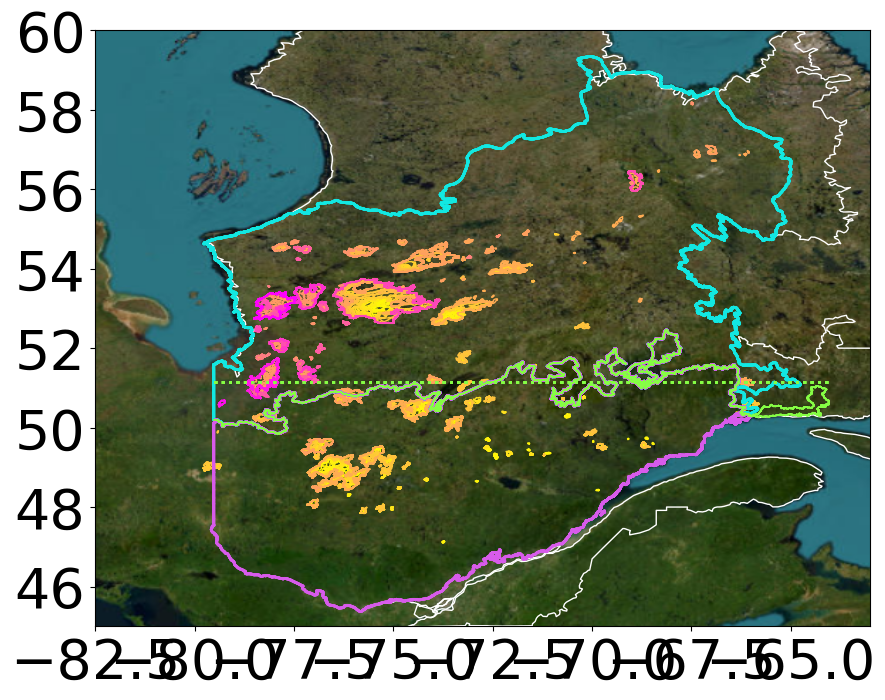

In [12]:
# Define the CartoPy CRS object.
#crs = ccrs.LambertConformal()
crs = ccrs.PlateCarree()

# This can be converted into a `proj4` string/dict compatible with GeoPandas
crs_proj4 = crs.proj4_init



proj_fires = proj_fires.to_crs(crs_proj4)


# The lat-long proj
noProj = ccrs.PlateCarree()
# The projection of the map
myProj = ccrs.LambertConformal(central_longitude=-73.24, central_latitude=51.9)
myProj._threshold = myProj._threshold/20.  # Set for higher precision of the projection



with mpl.rc_context({'font.size': 40}):
    #fig, ax = plt.subplots(subplot_kw=dict(projection=crs), figsize=(20, 20))
    plot = proj_fires.plot(facecolor="none",figsize=(10, 10), column = "days_since", 
    #proj_fires.plot(ax = ax, facecolor="none",figsize=(20, 20), column = "days_since", 
                           cmap = 'spring_r', #autumn_r
                           legend=False, 
                           legend_kwds={'ticks': [], "orientation":"horizontal"},)
    
    prov[prov.prov_name_en == 'Quebec'].plot(ax = plot, facecolor = "none", edgecolor = "white")

    
    eco_provs_n.plot(ax = plot, facecolor = "none", edgecolor = "#12e8e2", linewidths = 2) ##12e8e2 #c27ba0
    eco_provs_s.plot(ax = plot, facecolor = "none", edgecolor = "#d85beb", linewidths = 2) ##d85beb ##bf9000
    zones.plot(ax = plot, color = "#86fd45", linewidths = 1)
    zones_avg_line.plot(ax= plot, color = "#86fd45", linestyles='dotted', linewidths = 2)
    #scalebar = ScaleBar(1)
    #plot.add_artist(scalebar, rotation='horizontal-only')
    
    cx.add_basemap(ax = plot, source=cx.providers.Esri.WorldImagery, attribution = False, crs = proj_fires.crs.to_string())
                    #crs=gdf.crs.to_string(), source=cx.providers.NASAGIBS.ModisTerraBands367CR)
    plot.set_ylim(45, 60)
    plot.set_xlim(-82.5, -63)
    plot.set_aspect('equal', adjustable='box')
    #plot.tick_params(axis='x', labelrotation=180)
        
plt.savefig('Quebec_largefire.png', dpi = 900, transparent = True)

In [13]:
plt.show()

In [14]:
#proj_fires

In [15]:
# import cartopy.crs as ccrs
# import cartopy
# import matplotlib.pyplot as plt
# import matplotlib.path as mpath

# #crs = ccrs.LambertConformal()
# #crs = ccrs.PlateCarree()
# crs = ccrs.LambertConformal(central_longitude=-73.24, central_latitude=51.49)
# # This can be converted into a `proj4` string/dict compatible with GeoPandas
# crs_proj4 = crs.proj4_init



# proj_fires = proj_fires.to_crs(crs_proj4)


# # The lat-long proj
# noProj = ccrs.PlateCarree()
# # The projection of the map

# central_longitude=-73.24
# central_latitude=51.49

# dist =  2

# myProj = ccrs.LambertConformal(central_longitude=-73.24, central_latitude=51.49)
# myProj._threshold = myProj._threshold/2.  # Set for higher precision of the projection

# ax = plt.axes(projection=myProj)

# # This plots parallel and meridian arcs around a target area that will be used ...
# #  as the map boundary

# minx = proj_fires.bounds.minx.min() - dist
# maxx = proj_fires.bounds.maxx.max() + dist
# miny = proj_fires.bounds.miny.min() - dist
# maxy = proj_fires.bounds.maxy.max() + dist

# [ax_hdl] = ax.plot([minx , maxx, maxx, minx , minx ], [miny, miny, maxy, maxy, miny],
#          color='black', linewidth=0.5, marker='none',
#          transform=noProj)
# # Get the `Path` of the plot
# tx_path = ax_hdl._get_transformed_path()
# path_in_data_coords, _ = tx_path.get_transformed_path_and_affine()

# # Use the path's vertices to create a polygon
# polygon = mpath.Path( path_in_data_coords.vertices )
# ax.set_boundary(polygon) #This masks-out unwanted part of the plot
# proj_fires.plot(ax = ax, facecolor="none", column = "days_since",
#                            cmap = 'autumn_r', 
#                            legend=True, 
#                            legend_kwds={'ticks': [], "orientation":"horizontal"},)

# ax.gridlines(draw_labels=True, x_inline=False, y_inline=False)
# #ax.add_feature(cartopy.feature.OCEAN, linewidth=.3, color='lightblue')
# #ax.add_feature(cartopy.feature.LAND, zorder=1, edgecolor='black')

# ax.title.set_text("Meridians and Parallels as Boundary")
# plt.show()

In [16]:
proj_fires.bounds

,minx,miny,maxx,maxy
0,-72.873635,50.635662,-72.830522,50.674100
1,-72.912428,50.630520,-72.830522,50.686359
2,-72.912428,50.630520,-72.830522,50.686359
3,-72.919675,50.630520,-72.819034,50.698470
4,-72.924596,50.629421,-72.810401,50.701278
...,...,...,...,...
2663,-72.801064,51.111703,-72.719654,51.184027
2664,-72.801064,51.111703,-72.692873,51.191695
2665,-72.802505,51.111703,-72.629401,51.200136
2666,-72.803062,51.097323,-72.622021,51.202806


In [17]:
proj_fires.bounds.minx

0      -72.873635
1      -72.912428
2      -72.912428
3      -72.919675
4      -72.924596
          ...    
2663   -72.801064
2664   -72.801064
2665   -72.802505
2666   -72.803062
2667   -72.833874
Name: minx, Length: 2534, dtype: float64